# Chapter 8: PET/CT — Measuring Function

<a href="https://colab.research.google.com/github/choilab-jefferson/medimage/blob/main/Chapter08_PET_CT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Every chapter so far measured **anatomy**: where tissue is, how much of it there is, how dense it is.
PET measures something different — how hard tissue is *working*.

The patient is injected with a glucose molecule carrying a radioactive fluorine atom (FDG). Cells
take up glucose in proportion to how much energy they are using, so wherever the tracer accumulates,
something is metabolically busy. Tumors usually are. So are the brain, the heart, and inflammation.

That makes PET a natural partner for CT rather than a replacement: CT says *where*, PET says *how
active*. They are acquired on the same machine, in the same session, which is why the modality is
written PET/CT.

By the end of this chapter you will be able to:

1. Explain **SUV**, the calibrated unit that makes PET quantitative — the PET counterpart of the
   Hounsfield unit.
2. Convert a PET series into SUV correctly, and say why doing it by hand is a bad idea.
3. Overlay PET on CT, which means resampling one onto the other's grid.
4. Measure uptake in an organ and compare it against a reference region.
5. Compare two scans of the same patient taken months apart, which is where PET earns its keep.

The data is from **ACRIN 6668**, a trial testing whether FDG-PET after chemoradiotherapy predicts
survival in non-small-cell lung cancer.

### Before you start

| | |
|---|---|
| **Builds on** | Chapter 1 (headers, spacing) and Chapter 4 (resampling onto a common grid) |
| **Downloads** | Three ACRIN series — two PET timepoints and one CT. Several hundred MB in total |
| **Longest wait** | The downloads, plus the TotalSegmentator run in section 3 — **around 10 minutes** on a CPU |
| **Beyond the setup cell** | `qradiomics`, `SimpleITK` and `TotalSegmentator`, installed by the setup cells |
| **Hardware** | A GPU runtime makes section 3 much faster, as in Chapter 6 |

One idea from Chapter 4 does the heavy lifting here: PET and CT are acquired on the same machine
but on **different grids**, so every overlay and every organ measurement in this chapter is a
resampling problem before it is anything else.

## Setup

In [1]:
# --- Setup: Google Colab (primary) and local checkout (testing) ---------------
REPO_URL = "https://github.com/choilab-jefferson/medimage.git"
REPO_DIR = "medimage"

import os
import pathlib
import subprocess
import sys

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    # On Colab the repository is not present yet, so clone it and install the
    # few packages that are not part of the default runtime.
    if not pathlib.Path(REPO_DIR).is_dir():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_DIR)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "pydicom", "remotezip"],
        check=True,
    )
else:
    # Locally the notebook already lives inside the repository; walk up until
    # we find the module that the notebooks import.
    root = pathlib.Path.cwd().resolve()
    while not (root / "medimage_data.py").is_file() and root != root.parent:
        root = root.parent
    os.chdir(root)

print("Running on Colab:", IN_COLAB)
print("Working directory:", pathlib.Path.cwd().name)

Running on Colab: False
Working directory: medimage


In [2]:
import subprocess
import sys

try:
    import qradiomics  # noqa: F401
    print("qradiomics already installed")
except ModuleNotFoundError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "qradiomics", "SimpleITK"],
                   check=True)
    print("installed")

qradiomics already installed


In [3]:
import os
import pathlib

import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk

import medimage_data as md
from qradiomics.io.dicom import read_pet_suv

WORK = pathlib.Path("work")
WORK.mkdir(exist_ok=True)

pet_dir = md.fetch_acrin(timepoint=0)

data/acrin/001_PT_0: 355 files (study date 1960-01-10)
Source: Machtay M, Duan F, Siegel BA, et al. (2013). ACRIN 6668/RTOG 0235 trial; data from The Cancer Imaging Archive: ACRIN-NSCLC-FDG-PET. https://doi.org/10.7937/tcia.2019.30ilqfcl  (TCIA data usage policy)


## 1. Why raw PET numbers mean nothing

A PET scanner counts radioactive decays per unit volume. That count depends on things that have
nothing to do with the patient's biology:

- **How much tracer was injected.** Twice the dose, roughly twice the counts.
- **How big the patient is.** The same dose spread through a larger body is more dilute.
- **How long you waited.** Fluorine-18 has a half-life of about 110 minutes, so the signal is
  visibly decaying while the scan happens.

Two scans of the same patient can differ by a factor of several for those reasons alone. Comparing
raw counts across patients, or even across visits, is meaningless.

**SUV** — standardized uptake value — divides all of that out:

$$\text{SUV} = \frac{\text{activity per mL in the voxel}}{\text{injected dose} \;/\; \text{body weight}}$$

The denominator is what the concentration *would* be if the tracer spread perfectly evenly. So SUV
is a ratio against uniform distribution:

- **SUV = 1** — average uptake, exactly what uniform spreading would give.
- **SUV ≈ 2** — normal liver, the usual internal reference.
- **SUV > 2.5** — the conventional threshold for suspicious uptake.

Like the Hounsfield unit, this is a calibrated scale, and it is calibrated for the same reason: so
that a number measured in one hospital means the same thing in another.

### Do not compute it by hand

The formula is three lines. Applying it correctly is not, because the DICOM header can express
activity in several different unit systems, and each needs different handling:

| Stored units | What has to be done |
|---|---|
| `BQML` — becquerels per mL | decay-correct the dose from injection time to scan time, then divide by dose per weight |
| `CNTS` — raw vendor counts | apply a vendor-private scale factor first |
| `GML` — already SUV | pass straight through |

Get the decay correction wrong and every number is off by a factor that looks entirely plausible.
`qradiomics` implements the QIBA vendor-neutral standard for this, so we use it rather than
reinventing it.

In [4]:
suv_result = read_pet_suv(str(pet_dir))
suv_image = suv_result.image
suv = sitk.GetArrayFromImage(suv_image)

print(f"stored units    : {suv_result.units}")
print(f"conversion factor: {suv_result.suv_factor:.3e}")
print(f"estimated?       : {suv_result.estimated}   (True would mean a header value was missing)")
print()
print(f"array   : {suv.shape}")
print(f"spacing : {tuple(round(v, 2) for v in suv_image.GetSpacing())} mm")
print(f"SUV range: {suv.min():.2f} to {suv.max():.1f}")

stored units    : BQML
conversion factor: 1.893e-04
estimated?       : False   (True would mean a header value was missing)

array   : (355, 128, 128)
spacing : (5.31, 5.31, 2.5) mm
SUV range: 0.00 to 66.7


In [5]:
inside = suv > 0.5      # crude body mask: background reads essentially zero

print(f"median SUV in the body : {np.median(suv[inside]):.2f}")
print(f"95th percentile        : {np.percentile(suv[inside], 95):.2f}")
print(f"maximum anywhere       : {suv.max():.1f}")
print()
print("The maximum is almost always the bladder — the tracer is cleared in urine")
print("and collects there. It is not a finding.")

median SUV in the body : 0.81
95th percentile        : 2.77
maximum anywhere       : 66.7

The maximum is almost always the bladder — the tracer is cleared in urine
and collects there. It is not a finding.


## 2. Putting PET on top of CT

PET and CT are acquired together but not on the same grid. PET voxels here are about 5 mm across
and CT voxels about 1 mm, so before the two can be overlaid, one has to be resampled onto the other.

Resample the **PET onto the CT**, not the other way round: interpolating PET up loses nothing that
matters, while downsampling the CT would throw away the anatomical detail that is the whole reason
for having it.

This is Chapter 4's resampling, with the geometry read from the headers rather than guessed —
`sitk.Resample` uses the position and orientation of both images, so the alignment comes from the
scanner rather than from us lining things up by eye.

In [6]:
ct_dir = md.fetch_acrin(modality="CT", description="Abd.CT 5.0 B30s", timepoint=0)

nifti = WORK / "acrin_ct.nii.gz"
if not nifti.exists():
    reader = sitk.ImageSeriesReader()
    reader.SetFileNames(reader.GetGDCMSeriesFileNames(str(ct_dir)))
    sitk.WriteImage(reader.Execute(), str(nifti))

ct_image = sitk.ReadImage(str(nifti))
ct = sitk.GetArrayFromImage(ct_image).astype(np.float32)

pet_on_ct = sitk.Resample(suv_image, ct_image, sitk.Transform(),
                          sitk.sitkLinear, 0.0, sitk.sitkFloat32)
pet = sitk.GetArrayFromImage(pet_on_ct)

print(f"CT  : {ct.shape}, spacing {tuple(round(v, 2) for v in ct_image.GetSpacing())}")
print(f"PET : {suv.shape}, spacing {tuple(round(v, 2) for v in suv_image.GetSpacing())}")
print(f"PET resampled onto the CT grid: {pet.shape}")

data/acrin/001_CT_0: 356 files (study date 1960-01-10)
Source: Machtay M, Duan F, Siegel BA, et al. (2013). ACRIN 6668/RTOG 0235 trial; data from The Cancer Imaging Archive: ACRIN-NSCLC-FDG-PET. https://doi.org/10.7937/tcia.2019.30ilqfcl  (TCIA data usage policy)


CT  : (356, 512, 512), spacing (0.98, 0.98, 2.5)
PET : (355, 128, 128), spacing (5.31, 5.31, 2.5)
PET resampled onto the CT grid: (356, 512, 512)


## 3. Finding the heart

The clinical question this chapter builds toward is about the heart, so we need to know which
voxels it occupies. As in Chapter 6, that is anatomy, and TotalSegmentator supplies it.

In [7]:
import shutil


def totalsegmentator_binary():
    for candidate in [shutil.which("TotalSegmentator"),
                      ".venv-ts/bin/TotalSegmentator",
                      str(pathlib.Path(sys.executable).parent / "TotalSegmentator")]:
        if candidate and pathlib.Path(candidate).exists():
            return candidate
    return None


def run_segmentation(args):
    # Jupyter exports MPLBACKEND=module://matplotlib_inline.backend_inline.
    # TotalSegmentator installed in its own environment rejects that value and
    # dies before it starts, so drop the variable from the child's environment.
    env = {k: v for k, v in os.environ.items() if k != "MPLBACKEND"}
    subprocess.run(args, check=True, env=env)


organs_dir = WORK / "acrin_organs"

if not (organs_dir / "heart.nii.gz").exists():
    binary = totalsegmentator_binary()
    if binary is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "TotalSegmentator"],
                       check=True)
        binary = totalsegmentator_binary()
    run_segmentation([binary, "-i", str(nifti), "-o", str(organs_dir),
                      "--roi_subset", "heart", "liver"])

heart = sitk.GetArrayFromImage(sitk.ReadImage(str(organs_dir / "heart.nii.gz"))) > 0
liver = sitk.GetArrayFromImage(sitk.ReadImage(str(organs_dir / "liver.nii.gz"))) > 0

for name, mask in [("heart", heart), ("liver", liver)]:
    slices = np.where(mask.any(axis=(1, 2)))[0]
    print(f"{name:6s}: {mask.sum():>8} voxels, slices {slices.min()}..{slices.max()}")

heart :   225501 voxels, slices 207..254
liver :   514223 voxels, slices 165..212


### The liver is the yardstick

PET readings drift with scanner, reconstruction and how long after injection the scan ran. So a
reading is judged against a reference region in the *same* scan, and the liver is the standard
choice: large, uniform, and metabolically steady. Normal liver sits around SUV 2.

If the liver reads far from that, the problem is usually the conversion or the acquisition, not the
patient. It is a sanity check on the whole pipeline before any finding is interpreted.

In [8]:
print(f"liver SUV : mean {pet[liver].mean():.2f}   median {np.median(pet[liver]):.2f}")
print(f"heart SUV : mean {pet[heart].mean():.2f}   max {pet[heart].max():.2f}   "
      f"95th pct {np.percentile(pet[heart], 95):.2f}")

liver SUV : mean 2.27   median 2.33
heart SUV : mean 1.07   max 5.03   95th pct 1.78


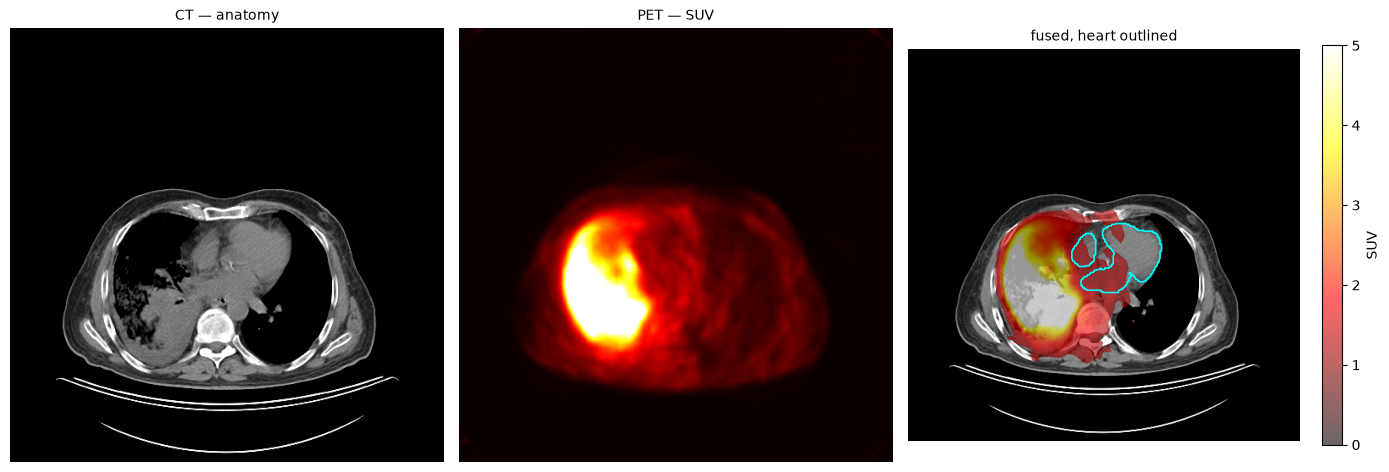

In [9]:
z = int(np.median(np.where(heart.any(axis=(1, 2)))[0]))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
axes[0].imshow(ct[z], cmap="gray", vmin=-160, vmax=240)
axes[0].set_title("CT — anatomy", fontsize=10)

axes[1].imshow(pet[z], cmap="hot", vmin=0, vmax=5)
axes[1].set_title("PET — SUV", fontsize=10)

axes[2].imshow(ct[z], cmap="gray", vmin=-160, vmax=240)
overlay = axes[2].imshow(np.where(pet[z] > 1.0, pet[z], np.nan),
                         cmap="hot", vmin=0, vmax=5, alpha=0.6)
axes[2].contour(heart[z], colors="cyan", linewidths=1.2)
axes[2].set_title("fused, heart outlined", fontsize=10)
plt.colorbar(overlay, ax=axes[2], fraction=0.046, label="SUV")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Why cardiac uptake is worth measuring

Healthy heart muscle can burn either glucose or fatty acids, and which it prefers depends on when
the patient last ate. After the long fast required before a PET scan, most hearts switch to fatty
acids and go quiet on FDG. Some do not.

That variability was long treated as a nuisance to be suppressed. More recently it has become a
signal in its own right: raised cardiac FDG uptake reflects inflammation and metabolic stress in the
myocardium, and in patients about to receive radiotherapy to the chest — where the heart sits inside
or beside the treatment field — that may say something about who will suffer cardiac injury later.

Choi et al. (JCO Clinical Cancer Informatics, 2024) built a model around exactly this. Working from
pretreatment PET/CT in lung cancer patients, they extracted 210 functional radiomics features from
cardiac regions, reduced them to 9 by Wilcoxon testing, hierarchical clustering and recursive
feature elimination, and classified cardiac FDG uptake into **no uptake, diffuse uptake and focal
uptake**. Across 209 scans from three populations the model reached 93% accuracy in training and
80% and 92% in two external validation sets.

We can measure the raw quantity that pattern classification starts from.

In [10]:
values = pet[heart]

print("cardiac FDG uptake for this patient")
print(f"  mean SUV                {values.mean():6.2f}")
print(f"  max  SUV                {values.max():6.2f}")
print(f"  fraction above SUV 2.5  {np.count_nonzero(values > 2.5) / values.size:6.1%}")
print(f"  fraction above SUV 5    {np.count_nonzero(values > 5.0) / values.size:6.1%}")
print()
print("A suppressed heart sits near the blood-pool level, around SUV 1-2, with")
print("almost nothing above 2.5. Diffuse uptake raises the whole distribution;")
print("focal uptake leaves the mean low but produces a hot spot.")

cardiac FDG uptake for this patient
  mean SUV                  1.07
  max  SUV                  5.03
  fraction above SUV 2.5    1.1%
  fraction above SUV 5      0.0%

A suppressed heart sits near the blood-pool level, around SUV 1-2, with
almost nothing above 2.5. Diffuse uptake raises the whole distribution;
focal uptake leaves the mean low but produces a hot spot.


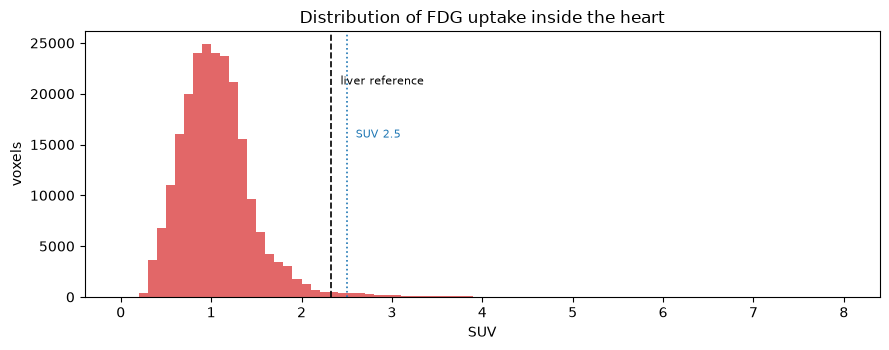

In [11]:
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(values, bins=80, range=(0, 8), color="tab:red", alpha=0.7)
ax.axvline(np.median(pet[liver]), color="black", linestyle="--", linewidth=1.2)
ax.text(np.median(pet[liver]) + 0.1, ax.get_ylim()[1] * 0.8, "liver reference", fontsize=8)
ax.axvline(2.5, color="tab:blue", linestyle=":", linewidth=1.2)
ax.text(2.6, ax.get_ylim()[1] * 0.6, "SUV 2.5", fontsize=8, color="tab:blue")
ax.set_xlabel("SUV")
ax.set_ylabel("voxels")
ax.set_title("Distribution of FDG uptake inside the heart")
plt.tight_layout()
plt.show()

## 5. The same patient, months later

ACRIN 6668 scanned patients before and after chemoradiotherapy, and the trial's question was whether
the *change* predicted survival. Change is often more informative than any single value, because
each patient acts as their own control — scanner, protocol and body size mostly cancel out.

Features built this way are called **delta radiomics**, and `qr delta` computes them across
timepoints for a whole cohort. Here we do the simplest possible version by hand.

In [12]:
follow_up = read_pet_suv(str(md.fetch_acrin(timepoint=1, quiet=True)))
suv_late = sitk.GetArrayFromImage(follow_up.image)

body_early = suv > 0.5
body_late = suv_late > 0.5

print(f"{'':22}{'before':>10}{'after':>10}{'change':>10}")
for label, fn in [("maximum SUV", np.max),
                  ("95th percentile", lambda a: np.percentile(a, 95)),
                  ("median in body", np.median)]:
    a, b = fn(suv[body_early]), fn(suv_late[body_late])
    print(f"{label:22}{a:>10.2f}{b:>10.2f}{b - a:>+10.2f}")

                          before     after    change
maximum SUV                66.72     23.24    -43.48
95th percentile             2.77      2.72     -0.05
median in body              0.81      1.14     +0.33


The maximum drops sharply between the two scans. Read that carefully, though: this comparison is
across the whole body, and the two scans do not cover exactly the same length of patient. A drop in
the whole-body maximum could equally mean the bladder was fuller on one day.

Doing this properly means measuring **the same anatomical region** on both scans, which means
registering them first — Chapter 4's problem, on a much harder pair, since the patient is positioned
differently and the anatomy itself has changed. That is why the tooling matters:

```
qr tcia download →  qr convert  →  qr extract -p acrin
                                        ↓
                    qr delta --pair post_minus_pre=post-pre
                                        ↓
                    qr analyze survival --outcome OS_months --event OS_event
```

Chapter 13 runs a pipeline of exactly this shape end to end, and checks the result against a
published number.

## Limitations

- **One patient.** Everything above is a demonstration of the measurement, not a finding.
- **The uptake pattern is not classified.** We measured the distribution the paper's features are
  built from; the classification itself needs the reduced feature set and a trained model.
- **The two timepoints were not registered**, so the change figures compare whole scans rather than
  matched regions.
- **SUV normalized by body weight** is the common convention but not the only one; lean body mass
  (SUL) is less sensitive to obesity, and the choice shifts every number.

## Recap

| | |
|---|---|
| **Raw PET counts mean nothing** | They depend on the injected dose, the patient's weight, and how long you waited. Two scans of the same patient are not comparable as counts |
| **SUV** | The calibration that fixes it: measured concentration ÷ (injected dose ÷ body weight). The PET counterpart of the Hounsfield unit |
| **Do not compute it by hand** | Decay correction, units and the several header fields involved are where the errors live. Use the library, which also tells you when it had to *estimate* a missing field |
| **Fusion** | PET onto the CT grid — Chapter 4's resampling, with `order=1` for the image |
| **A yardstick** | Liver SUV sits near 2 in a normal scan, which makes it the reference the clinic reads other uptake against |
| **Change over time** | Where PET earns its keep — but only if you compare *the same region*, which means registering first |

The last row is the honest ending of this chapter. The whole-body maximum dropped sharply between
the two timepoints, and that number is not trustworthy: the two scans do not cover the same length
of patient, so a fuller bladder would produce the same drop. Comparing properly requires
registration, on a hard pair where the patient is positioned differently *and* the anatomy has
changed.

**Next:** that is Part II finished — CT, MR and PET, each with its own calibrated quantity. Part III
turns to the quantitative methods built on top of them, starting with Chapter 9 on what a radiomics
feature actually is. Chapter 10 then takes on the registration problem this chapter just ran into.

## Exercises

1. Compute the heart-to-liver SUV ratio. Why might a ratio be more comparable between patients than
   the heart SUV alone?

   *Hint:* both organs are measured on the same scan, so a ratio cancels anything that scaled the
   whole image — dose calibration, weight convention, uptake time. It cannot cancel anything that
   affected the two organs differently.

2. Segment the heart on the follow-up scan too and compare cardiac uptake at the two timepoints.
   Does the picture differ from the whole-body comparison above?

   *Hint:* this is the fix for the limitation stated above — a named organ instead of a whole-body
   maximum. Re-run section 3's segmentation on the `timepoint=1` CT. Expect a more modest and more
   believable change than the whole-body maximum showed.

3. `read_pet_suv` reports `estimated`. Find a series where it is `True`, and work out which header
   field was missing and what was assumed in its place.

   *Hint:* loop over a few patients and print the flag. `PatientWeight` is the usual absentee. Once
   you know what was substituted, work out which direction that pushes every SUV in the series.

4. Try `md.fetch_acrin(patient="ACRIN-NSCLC-FDG-PET-002")`. Does the liver still read near SUV 2?
   What would you conclude if it did not?

   *Hint:* the liver reference is only a yardstick because it is stable across patients. A reading
   far from 2 points at the calibration rather than at the liver — a missing weight, a wrong uptake
   time, or a dose unit misread. That is the check being demonstrated.

## References

- Choi W, Jia Y, Kwak J, Werner-Wasik M, Dicker AP, Simone NL, Storozynsky E, Jain V, Vinogradskiy Y.
  *Novel Functional Radiomics for Prediction of Cardiac Positron Emission Tomography Avidity in Lung
  Cancer Radiotherapy.* JCO Clinical Cancer Informatics. 2024.
  [PMID 38452302](https://pubmed.ncbi.nlm.nih.gov/38452302/)
- Machtay M, Duan F, Siegel BA, et al. *Prediction of survival by [18F]fluorodeoxyglucose positron
  emission tomography in patients with locally advanced non-small-cell lung cancer undergoing
  definitive chemoradiation therapy: results of the ACRIN 6668/RTOG 0235 trial.* J Clin Oncol.
  2013;31(30):3823–3830.
- [QIBA SUV standard](https://qibawiki.rsna.org/index.php/Standardized_Uptake_Value_(SUV))
- Boellaard R, Delgado-Bolton R, Oyen WJG, et al. *FDG PET/CT: EANM procedure guidelines for tumor
  imaging: version 2.0.* Eur J Nucl Med Mol Imaging. 2015;42(2):328–354.